In [12]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [30]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

# --- Specify your targets ---
SINGLE_RUN_PATH = "jdm8943-rochester-institute-of-technology/style-prompt-gen/qyen2rjq"   # entity/project/run_id
SWEEP_PATH      = "jdm8943-rochester-institute-of-technology/sweep-style-prompt-gen/nnsv2san" # entity/project/sweep_id


#  Baseline single run
single_run = api.run(SINGLE_RUN_PATH)
baseline = {
    "meteor":        single_run.summary.get("meteor_mean"),
    "bertscore_f1":  single_run.summary.get("bertscore_f1_mean"),
}

sweep = api.sweep(SWEEP_PATH)
sweep_rows = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))

    fold_metrics = {"vec_std": [], "mean_cosine_sim": []}
    for k in range(5):
        for m in fold_metrics:
            v = run.summary.get(f"fold_{k}/{m}")
            if v is not None:
                fold_metrics[m].append(v)

    sweep_rows.append({
        "num_turns":              run.config.get("num_turns"),
        "meteor":                 run.summary.get("test/meteor"),
        "bertscore_f1":           run.summary.get("test/bertscore_f1"),
        "fold_vec_std":           fold_metrics["vec_std"],
        "fold_mean_cosine_sim":   fold_metrics["mean_cosine_sim"],
    })



sweep_df = pd.DataFrame(sweep_rows).sort_values("num_turns").reset_index(drop=True)
print(sweep_df)


   num_turns    meteor  bertscore_f1  \
0          1  0.322822      0.901914   
1          3  0.286973      0.892474   
2          5  0.303278      0.898596   

                                        fold_vec_std  \
0  [0.05417851731181145, 0.045929018408060074, 0....   
1  [0.07029160112142563, 0.039122551679611206, 0....   
2  [0.5409739017486572, 0.5141145586967468, 0.573...   

                                fold_mean_cosine_sim  
0  [0.9958346486091614, 0.9972360134124756, 0.996...  
1  [0.993195414543152, 0.9976612329483032, 0.9939...  
2  [0.4018931686878204, 0.5850347876548767, 0.430...  


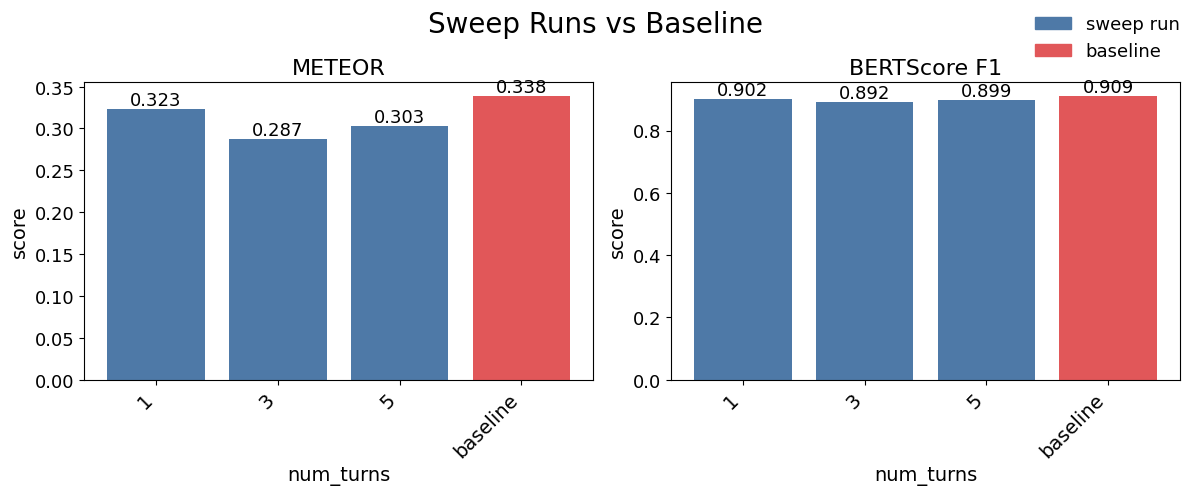

In [33]:
BASELINE_COLOR = "#e15759"
SWEEP_COLOR    = "#4e79a7"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sweep Runs vs Baseline", fontsize=20)

def bar_with_baseline(ax, sweep_df, metric, baseline_val, ylabel, title):
    labels = [str(t) for t in sweep_df["num_turns"]] + ["baseline"]

    values = list(sweep_df[metric]) + [baseline_val]
    colors = [SWEEP_COLOR] * len(sweep_df) + [BASELINE_COLOR]

    bars = ax.bar(range(len(labels)), values, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("num_turns", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, values):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)

bar_with_baseline(axes[0], sweep_df, "meteor",       baseline["meteor"],       "score", "METEOR")
bar_with_baseline(axes[1], sweep_df, "bertscore_f1", baseline["bertscore_f1"], "score", "BERTScore F1")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=SWEEP_COLOR, label="sweep run"),
                    Patch(color=BASELINE_COLOR, label="baseline")],
           loc="upper right", frameon=False, fontsize=13)

plt.tight_layout()
plt.savefig("sweep_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

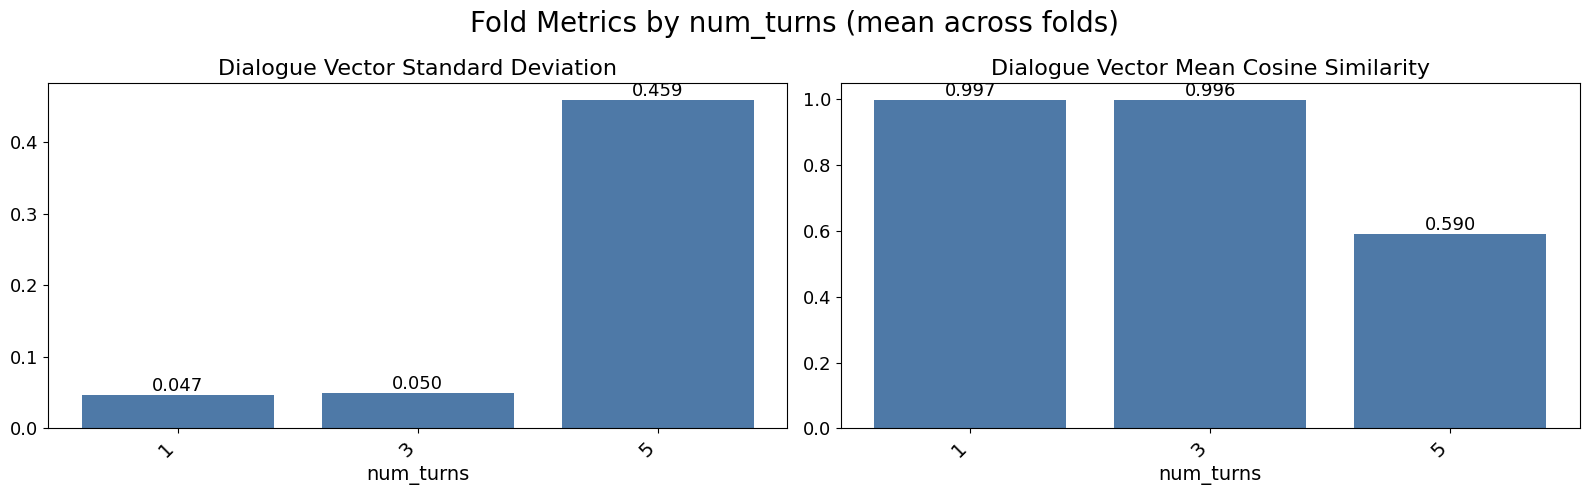

In [35]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Fold Metrics by num_turns (mean across folds)", fontsize=20)

fold_metrics_cfg = [
    ("fold_vec_std",         "Dialogue Vector Standard Deviation"),
    ("fold_mean_cosine_sim", "Dialogue Vector Mean Cosine Similarity"),
]

for ax, (col, title) in zip(axes, fold_metrics_cfg):
    means = [np.mean(vals) if vals else float("nan") for vals in sweep_df[col]]
    labels = [str(t) for t in sweep_df["num_turns"]]

    bars = ax.bar(range(len(labels)), means, color=SWEEP_COLOR)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("num_turns", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, means):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)

plt.tight_layout()
plt.savefig("fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()